# Menyelesaikan Permasalahan Institusi Pendidikan
## Prediksi Dropout Mahasiswa — Jaya Jaya Institut

**Nama:** Ratu Chairunisa
**Proyek:** Submission Akhir — Data Science, Dicoding

---


## 1. Business Understanding

### Latar Belakang
Jaya Jaya Institut adalah institusi pendidikan tinggi yang telah berdiri sejak tahun 2000 dan
telah meluluskan banyak mahasiswa dengan reputasi baik. Namun, institusi ini menghadapi
tantangan berupa **tingginya angka dropout (mahasiswa tidak menyelesaikan pendidikan)**.

Angka dropout yang tinggi berdampak pada:
- Reputasi dan akreditasi institusi
- Efisiensi penggunaan sumber daya pendidikan (dosen, fasilitas, beasiswa)
- Kesempatan mahasiswa untuk menyelesaikan pendidikan dan mengembangkan karier

### Permasalahan Bisnis
1. Institusi belum memiliki cara sistematis untuk **mendeteksi secara dini** mahasiswa yang
   berisiko dropout.
2. Tanpa deteksi dini, bimbingan khusus (akademik, finansial, maupun personal) sulit
   diberikan tepat waktu kepada mahasiswa yang membutuhkan.
3. Manajemen belum memiliki *dashboard* terpusat untuk memonitor performa dan
   faktor-faktor risiko dropout mahasiswa secara berkelanjutan.

### Cakupan Proyek
1. Melakukan analisis data performa mahasiswa untuk memahami pola dan faktor yang
   berkaitan dengan dropout.
2. Membangun model *machine learning* untuk memprediksi status mahasiswa
   (Dropout / Enrolled / Graduate).
3. Membuat *dashboard* bisnis untuk memonitor metrik-metrik penting terkait performa
   dan risiko dropout mahasiswa.
4. Membangun *prototype* sistem prediksi berbasis Streamlit yang siap digunakan oleh
   pihak institusi.
5. Merumuskan *action items* berbasis data untuk membantu institusi menurunkan
   angka dropout.

### Persiapan

**Sumber data:** [Students' Performance Dataset](https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/data.csv)

**Setup environment:**
```bash
python -m venv venv
source venv/bin/activate      # Windows: venv\Scripts\activate
pip install -r requirements.txt
jupyter notebook notebook/
```


## 2. Data Understanding

Dataset berisi data mahasiswa mencakup informasi demografis, sosial-ekonomi, latar
belakang pendidikan sebelumnya, serta performa akademik pada semester 1 dan 2.
Target (`Status`) memiliki 3 kelas: **Dropout**, **Enrolled**, **Graduate**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)


In [2]:
# Memuat dataset (delimiter titik koma sesuai sumber asli)
df = pd.read_csv('../data/data_raw.csv', sep=';')
print("Ukuran data:", df.shape)
df.head()


Ukuran data: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [4]:
# Cek missing value dan duplikasi
print("Total missing value:", df.isnull().sum().sum())
print("Total baris duplikat:", df.duplicated().sum())


Total missing value: 0
Total baris duplikat: 0


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


/tmp/ipykernel_638/2348691616.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')


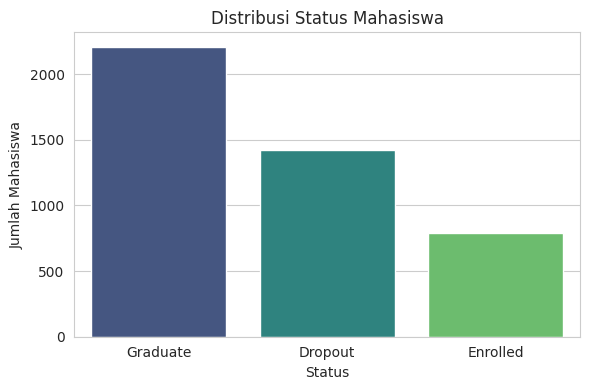

In [6]:
# Distribusi kelas target
status_counts = df['Status'].value_counts()
print(status_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')
plt.title('Distribusi Status Mahasiswa')
plt.ylabel('Jumlah Mahasiswa')
plt.xlabel('Status')
plt.tight_layout()
plt.savefig('../dashboard/status_distribution.png', dpi=120)
plt.show()


**Insight:** Dari total 4.424 mahasiswa, sekitar 32% berstatus *Dropout*, 50% *Graduate*,
dan 18% masih *Enrolled*. Angka dropout sebesar ~32% ini cukup signifikan dan menjadi
dasar urgensi proyek ini.


/tmp/ipykernel_638/54428396.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_approved', ax=axes[0], palette='Set2')
/tmp/ipykernel_638/54428396.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', ax=axes[1], palette='Set2')


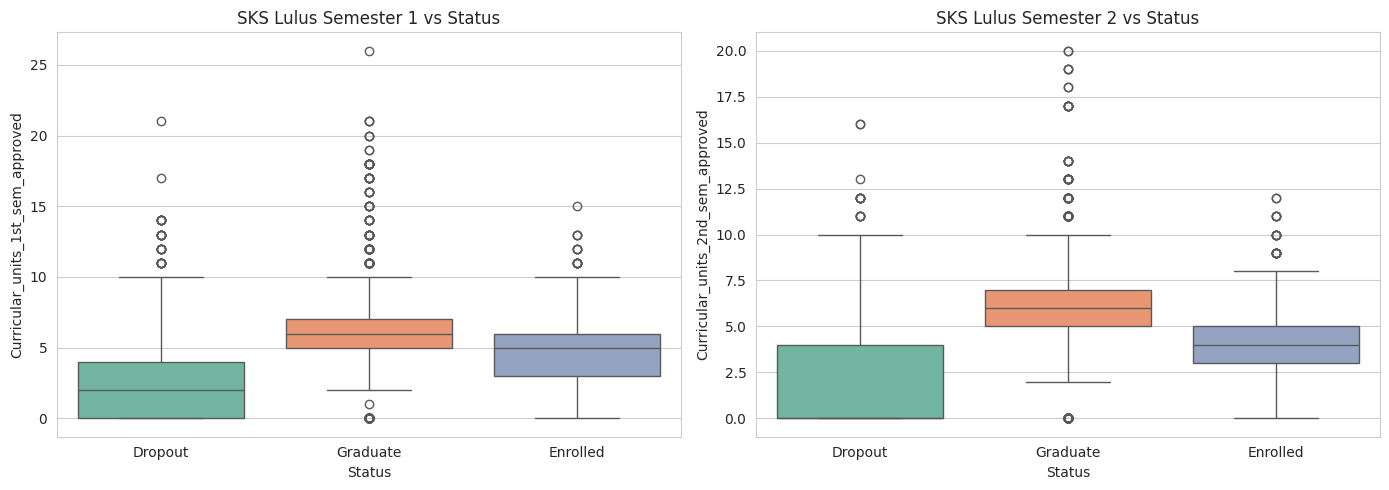

In [7]:
# Hubungan performa akademik semester 1 & 2 terhadap status
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_approved', ax=axes[0], palette='Set2')
axes[0].set_title('SKS Lulus Semester 1 vs Status')
sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', ax=axes[1], palette='Set2')
axes[1].set_title('SKS Lulus Semester 2 vs Status')
plt.tight_layout()
plt.savefig('../dashboard/units_approved_vs_status.png', dpi=120)
plt.show()


**Insight:** Mahasiswa yang berstatus *Dropout* secara konsisten memiliki jumlah SKS
yang lulus (approved) jauh lebih rendah pada semester 1 maupun semester 2 dibanding
mahasiswa *Graduate*. Ini mengindikasikan bahwa **performa akademik di semester-semester
awal adalah sinyal risiko dropout yang kuat**.


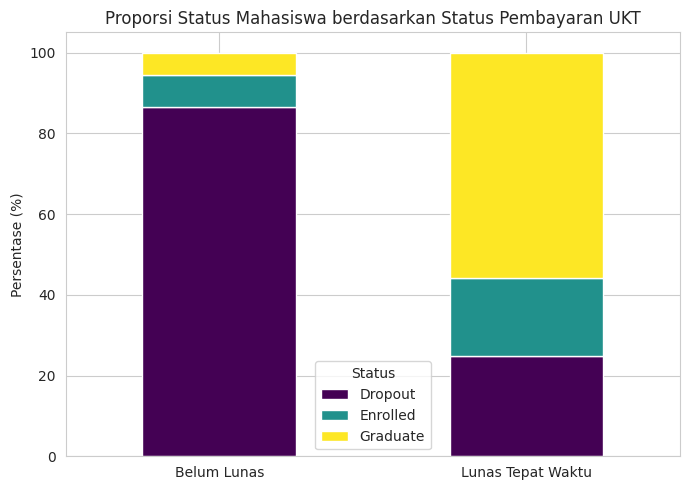

In [8]:
# Status pembayaran uang kuliah vs status mahasiswa
tuition_ct = pd.crosstab(df['Tuition_fees_up_to_date'], df['Status'], normalize='index') * 100
tuition_ct.index = ['Belum Lunas', 'Lunas Tepat Waktu']
tuition_ct.plot(kind='bar', stacked=True, figsize=(7,5), colormap='viridis')
plt.title('Proporsi Status Mahasiswa berdasarkan Status Pembayaran UKT')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../dashboard/tuition_vs_status.png', dpi=120)
plt.show()


**Insight:** Mahasiswa yang **belum melunasi uang kuliah tepat waktu** memiliki proporsi
dropout yang jauh lebih tinggi dibanding yang lunas tepat waktu. Faktor finansial
tampak menjadi salah satu pendorong dropout yang penting.


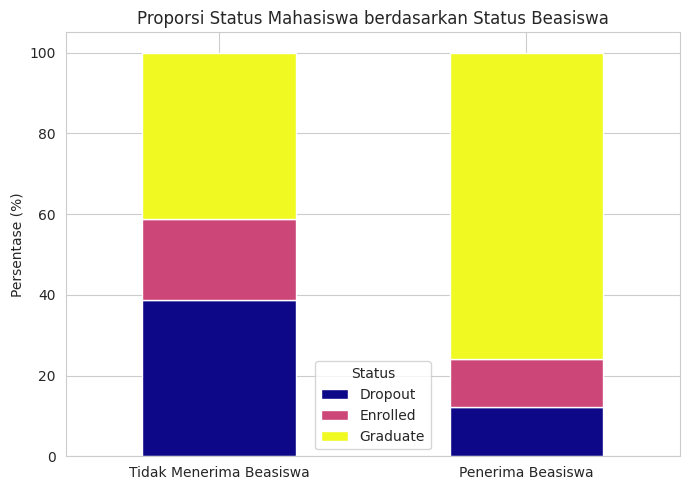

In [9]:
# Beasiswa vs status
scholarship_ct = pd.crosstab(df['Scholarship_holder'], df['Status'], normalize='index') * 100
scholarship_ct.index = ['Tidak Menerima Beasiswa', 'Penerima Beasiswa']
scholarship_ct.plot(kind='bar', stacked=True, figsize=(7,5), colormap='plasma')
plt.title('Proporsi Status Mahasiswa berdasarkan Status Beasiswa')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../dashboard/scholarship_vs_status.png', dpi=120)
plt.show()


**Insight:** Penerima beasiswa menunjukkan tingkat *Graduate* yang lebih tinggi dan
tingkat *Dropout* yang lebih rendah dibanding non-penerima beasiswa, mendukung
pentingnya dukungan finansial dalam retensi mahasiswa.


/tmp/ipykernel_638/2834792280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Age_at_enrollment', palette='coolwarm')


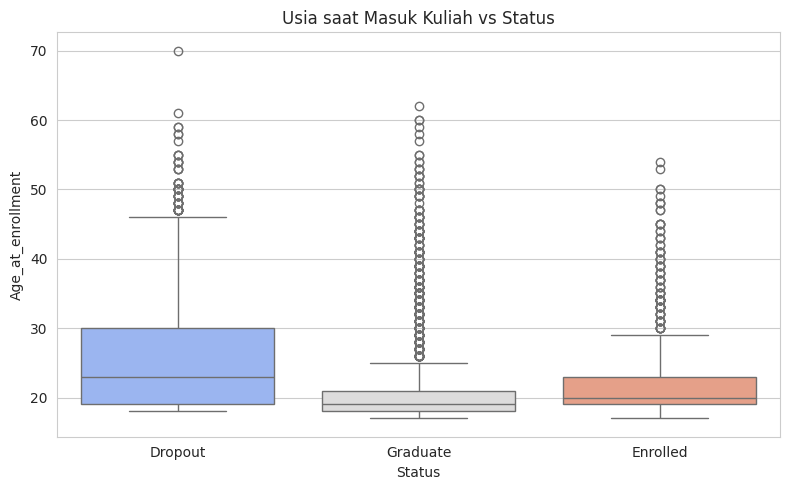

In [10]:
# Usia saat masuk kuliah vs status
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Status', y='Age_at_enrollment', palette='coolwarm')
plt.title('Usia saat Masuk Kuliah vs Status')
plt.tight_layout()
plt.savefig('../dashboard/age_vs_status.png', dpi=120)
plt.show()


**Insight:** Mahasiswa yang dropout maupun masih *Enrolled* cenderung memiliki usia
masuk kuliah yang lebih tua dan variasi usia yang lebih besar dibanding mahasiswa
yang berhasil *Graduate*, yang cenderung masuk pada usia lebih muda dan konsisten.


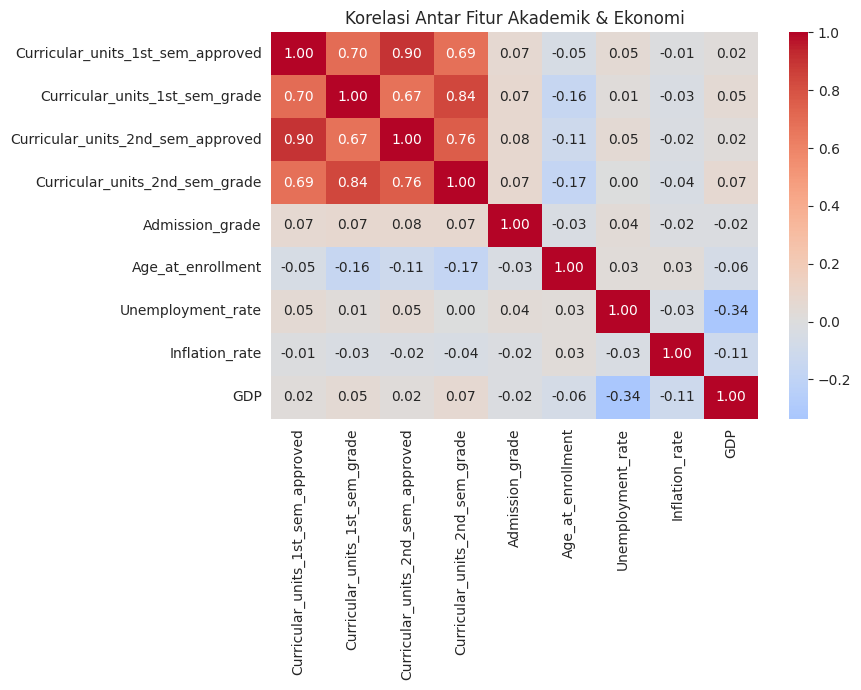

In [11]:
# Matriks korelasi fitur numerik akademik utama
academic_cols = ['Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
                  'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
                  'Admission_grade', 'Age_at_enrollment', 'Unemployment_rate',
                  'Inflation_rate', 'GDP']
plt.figure(figsize=(9,7))
sns.heatmap(df[academic_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelasi Antar Fitur Akademik & Ekonomi')
plt.tight_layout()
plt.savefig('../dashboard/correlation_heatmap.png', dpi=120)
plt.show()


## 3. Data Preparation

Tahapan yang dilakukan:
1. Encoding target `Status` (Dropout/Enrolled/Graduate) menjadi numerik menggunakan `LabelEncoder`.
2. Seluruh fitur pada dataset sudah dalam bentuk numerik/terenkode sejak sumber data, sehingga
   tidak diperlukan encoding kategorikal tambahan.
3. Split data menjadi data latih (80%) dan data uji (20%) dengan stratifikasi pada target
   agar proporsi kelas tetap terjaga.
4. Standardisasi fitur numerik menggunakan `StandardScaler` agar seluruh fitur memiliki skala
   yang sebanding, penting untuk model berbasis jarak/pohon yang sensitif terhadap skala.


In [12]:
le_status = LabelEncoder()
df['Status_encoded'] = le_status.fit_transform(df['Status'])
print(dict(zip(le_status.classes_, le_status.transform(le_status.classes_))))

feature_cols = [c for c in df.columns if c not in ['Status', 'Status_encoded']]
X = df[feature_cols]
y = df['Status_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Train shape: (3539, 36) | Test shape: (885, 36)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Modeling

Model yang digunakan adalah **Random Forest Classifier**. Model ini dipilih karena:
- Mampu menangani hubungan non-linear antar fitur dengan baik.
- Relatif tahan terhadap outlier dan tidak memerlukan asumsi distribusi data tertentu.
- Menyediakan *feature importance* yang membantu interpretasi model bagi pihak institusi.
- Parameter `class_weight='balanced'` digunakan untuk mengatasi ketidakseimbangan kelas
  (kelas *Enrolled* memiliki jumlah sampel yang jauh lebih sedikit).


In [14]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)
print("Model berhasil dilatih.")


Model berhasil dilatih.


## 5. Evaluation


In [15]:
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"Akurasi     : {acc:.4f}")
print(f"Macro F1    : {f1_macro:.4f}\n")
print(classification_report(y_test, y_pred, target_names=le_status.classes_))


Akurasi     : 0.7571
Macro F1    : 0.7018

              precision    recall  f1-score   support

     Dropout       0.82      0.70      0.76       284
    Enrolled       0.49      0.52      0.50       159
    Graduate       0.82      0.88      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



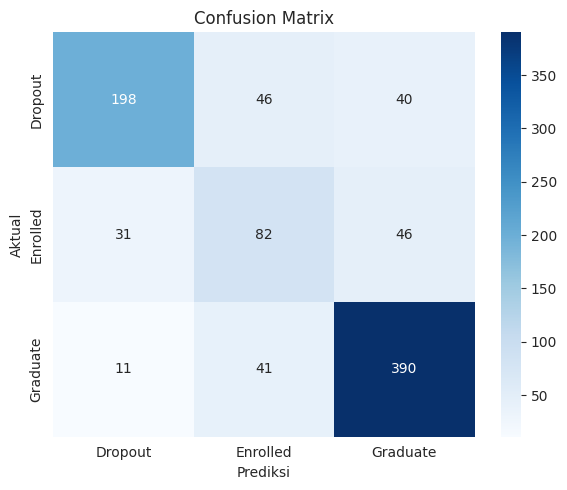

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_status.classes_, yticklabels=le_status.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig('../dashboard/confusion_matrix.png', dpi=120)
plt.show()


/tmp/ipykernel_638/3594387312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='mako')


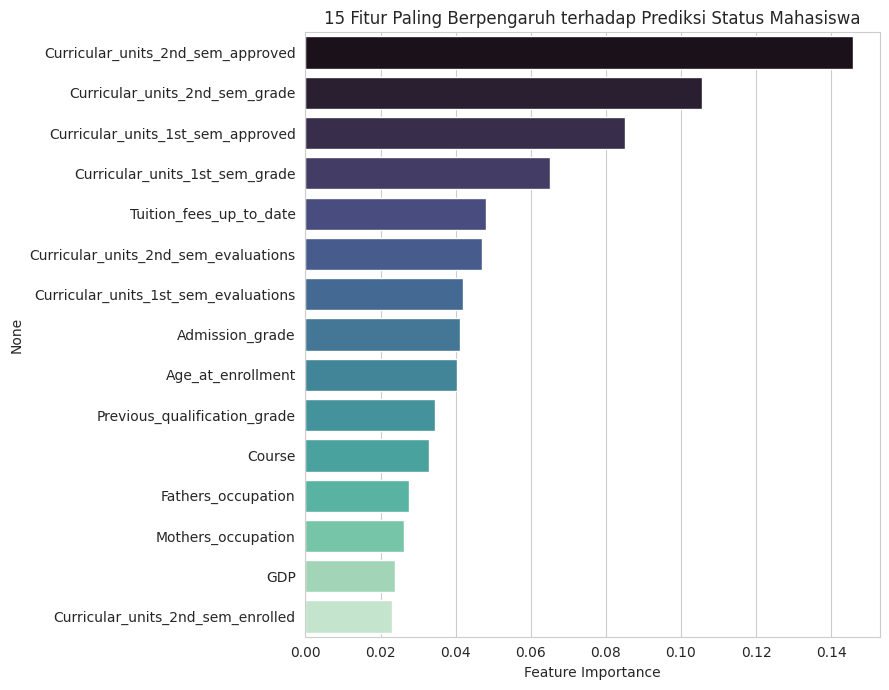

Curricular_units_2nd_sem_approved       0.145725
Curricular_units_2nd_sem_grade          0.105688
Curricular_units_1st_sem_approved       0.085098
Curricular_units_1st_sem_grade          0.065063
Tuition_fees_up_to_date                 0.048149
Curricular_units_2nd_sem_evaluations    0.046895
Curricular_units_1st_sem_evaluations    0.041986
Admission_grade                         0.041088
Age_at_enrollment                       0.040340
Previous_qualification_grade            0.034593
Course                                  0.032957
Fathers_occupation                      0.027551
Mothers_occupation                      0.026313
GDP                                     0.023952
Curricular_units_2nd_sem_enrolled       0.023168
dtype: float64

In [17]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9,7))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='mako')
plt.title('15 Fitur Paling Berpengaruh terhadap Prediksi Status Mahasiswa')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('../dashboard/feature_importance.png', dpi=120)
plt.show()

importances.head(15)


**Insight Evaluasi Model:**
- Model mencapai akurasi ±76% dan macro F1-score ±0.70 pada data uji.
- Performa terbaik dicapai pada kelas *Graduate* dan *Dropout* (precision & recall tinggi),
  sementara kelas *Enrolled* (mahasiswa yang masih aktif dan belum tentu arah statusnya)
  paling sulit diprediksi — hal ini wajar karena statusnya memang masih "di tengah".
- Fitur yang paling berpengaruh terhadap prediksi adalah jumlah SKS yang disetujui/lulus
  dan rata-rata nilai pada semester 1 & 2, diikuti oleh status pelunasan uang kuliah dan
  nilai admisi — sejalan dengan temuan pada tahap *Data Understanding*.


## 6. Menyimpan Model & Artefak untuk Deployment

Model beserta *scaler*, *label encoder*, dan daftar kolom fitur disimpan agar dapat
digunakan langsung oleh *prototype* Streamlit (`deployment/predict.py`) tanpa perlu
melatih ulang model.


In [18]:
joblib.dump(model, '../model/dropout_model.pkl')
joblib.dump(scaler, '../model/scaler.pkl')
joblib.dump(le_status, '../model/label_encoder.pkl')
joblib.dump(feature_cols, '../model/feature_columns.pkl')
importances.to_csv('../model/feature_importance.csv')
print("Seluruh artefak model berhasil disimpan di folder model/.")


Seluruh artefak model berhasil disimpan di folder model/.


## 7. Kesimpulan (Conclusion)

Berdasarkan proses analisis data dan pemodelan yang telah dilakukan, dapat disimpulkan:

1. **Angka dropout di Jaya Jaya Institut cukup tinggi**, yaitu sekitar 32% dari total
   mahasiswa dalam dataset, sehingga menjadi masalah yang layak mendapat prioritas
   penanganan.
2. **Performa akademik di semester-semester awal** (jumlah SKS yang lulus dan rata-rata
   nilai pada semester 1 & 2) merupakan **prediktor terkuat** terhadap risiko dropout.
   Mahasiswa dengan SKS lulus rendah pada semester awal berisiko jauh lebih tinggi
   untuk dropout.
3. **Faktor finansial berperan signifikan** — mahasiswa yang belum melunasi uang kuliah
   tepat waktu dan yang tidak menerima beasiswa cenderung memiliki tingkat dropout
   yang lebih tinggi.
4. **Usia saat masuk kuliah** juga berkontribusi — mahasiswa yang masuk pada usia lebih
   tua memiliki variasi status yang lebih besar (termasuk risiko dropout lebih tinggi)
   dibanding mahasiswa yang masuk pada usia standar (18-19 tahun).
5. Model **Random Forest Classifier** yang dibangun mampu memprediksi status mahasiswa
   (Dropout/Enrolled/Graduate) dengan **akurasi ±76%** dan **macro F1-score ±0.70**,
   sehingga cukup layak digunakan sebagai alat bantu deteksi dini bagi pihak institusi,
   dengan catatan hasil prediksi tetap perlu dikombinasikan dengan penilaian dari
   pihak akademik.

Model dan dashboard yang dihasilkan dari proyek ini diharapkan dapat membantu
Jaya Jaya Institut mendeteksi mahasiswa berisiko dropout **lebih dini**, sehingga
bimbingan khusus dapat diberikan tepat waktu dan angka dropout dapat ditekan.

Rekomendasi *action items* secara lebih detail dijabarkan pada berkas `README.md`.
